In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'dog.jpeg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(350, 233, 3)

In [3]:
pixels = img.reshape(-1, 3)
pixels = np.float32(pixels)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

panels = [('Original', img)]
for k in [2, 4, 6]:
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()].reshape(img.shape)
    panels.append((f'K={k}', segmented))
    print(f'K={k} cluster centers (RGB):')
    print(centers)

K=2 cluster centers (RGB):
[[180 147 142]
 [ 90  66  59]]


K=4 cluster centers (RGB):
[[166 124 115]
 [ 75  56  53]
 [200 181 182]
 [116  84  70]]


K=6 cluster centers (RGB):
[[198 133 120]
 [161 147 156]
 [209 193 192]
 [141 105  89]
 [ 73  55  53]
 [106  76  64]]


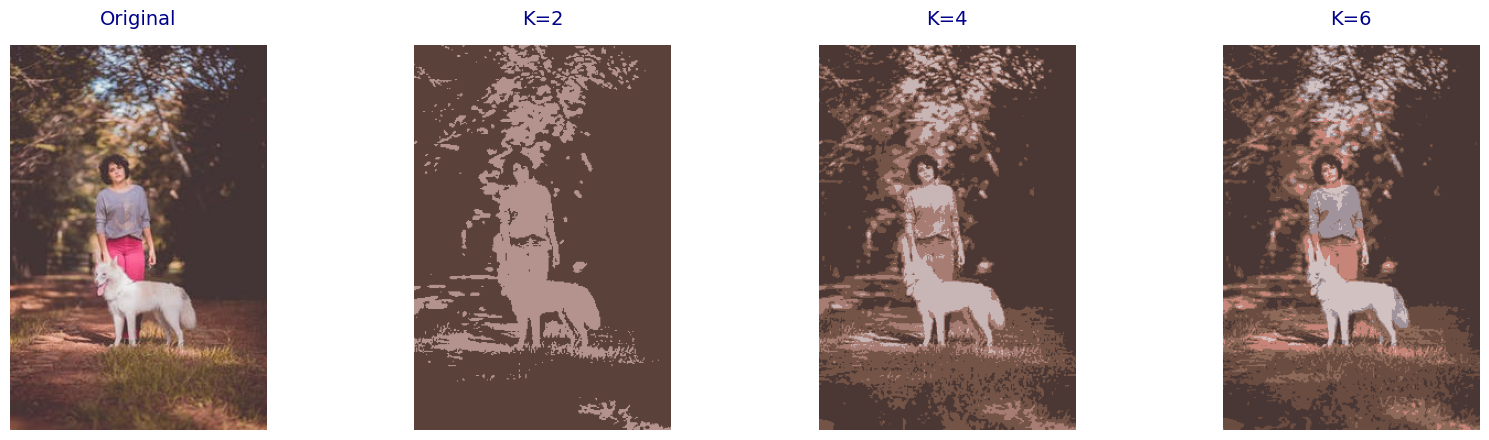

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, )
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
for title, im in panels[1:]:
    cv2.imwrite(f'output/task9_{title}.png', cv2.cvtColor(im, cv2.COLOR_RGB2BGR))

K=2: very different from the original, flat two tone, most simplified. Bright subjects (dog, person, light patches) vs dark background.
K=4: recognisable but posterized. Dog and lit ground separate from the dark foliage.
K=6: closest to the original, least simplified. Sweater and pink trousers also separate.

More K keeps more detail and color but simplifies less.